Probek: 8370 | wektor: 1764 | ekstrakcja: 22.5s


,kernel,C,scaler,class_weight,accuracy [%],F1-macro [%],czas [s]
0,rbf,10.0,nie,-,95.52,96.18,17.9
1,rbf,10.0,tak,-,95.22,95.91,17.6
2,rbf,1.0,tak,-,94.56,95.41,17.4
3,rbf,1.0,nie,-,94.50,95.38,16.2
4,linear,0.1,nie,-,92.83,94.05,10.4
5,rbf,0.1,nie,-,90.56,91.58,21.2
6,rbf,0.1,tak,-,90.14,91.14,20.8
7,linear,1.0,nie,-,89.84,91.53,11.0
8,linear,1.0,tak,-,89.25,91.06,9.8
9,linear,10.0,tak,-,89.25,91.06,9.8


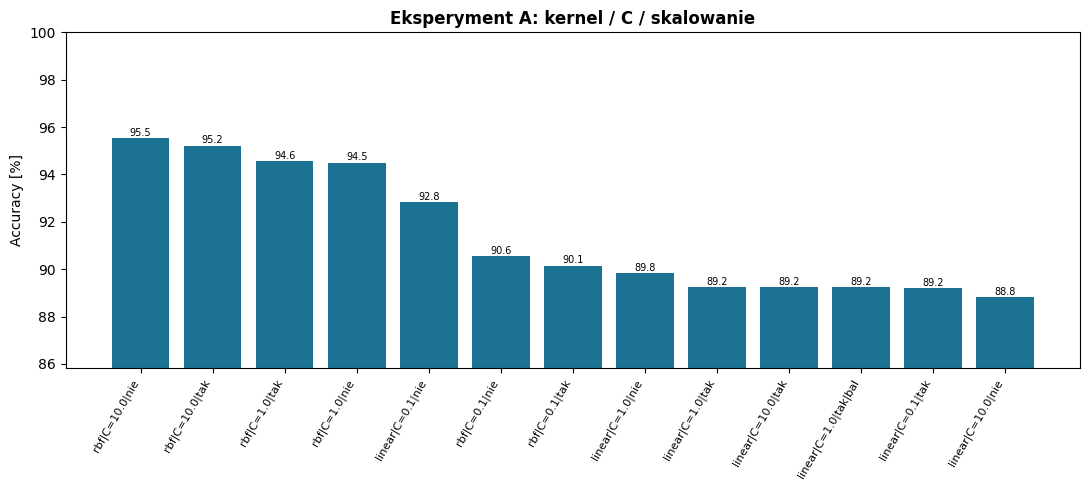

,orientations,pixels_per_cell,cells_per_block,wymiar,accuracy [%],ekstrakcja [s],projekt
0,6,8,2,1176,90.80,19.3,
1,9,8,2,1764,89.84,22.5,TAK
2,12,8,2,2352,89.84,19.7,
3,9,16,2,324,92.77,19.2,
4,9,8,3,2916,91.22,19.9,


In [2]:
import os, time, gc
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from IPython.display import display
import joblib

DATA_DIR     = '../data/db_balanced'
TEST_DIR     = '../data/test_images'
MODEL_PATH   = '../models/svm_model.pkl'
CACHE_DIR    = './cache_features'
RESULTS_DIR  = './wyniki_eksperymentow'
IMG_SIZE     = (64, 64)
RANDOM_STATE = 42
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


def segment_roi(img, sv_min=(30, 40)):
    s_min, v_min = sv_min
    hsv = cv2.cvtColor(cv2.GaussianBlur(img, (5, 5), 0), cv2.COLOR_BGR2HSV)
    lo1 = np.array([0, s_min, v_min], np.uint8); hi1 = np.array([10, 255, 255], np.uint8)
    lo2 = np.array([160, s_min, v_min], np.uint8); hi2 = np.array([180, 255, 255], np.uint8)
    loy = np.array([20, 100, 100], np.uint8); hiy = np.array([35, 255, 255], np.uint8)
    mask = cv2.inRange(hsv, lo1, hi1) | cv2.inRange(hsv, lo2, hi2) | cv2.inRange(hsv, loy, hiy)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        bx, by, bw, bh = cv2.boundingRect(max(contours, key=cv2.contourArea))
        m = int(0.05 * bw)
        x1, y1 = max(0, bx - m), max(0, by - m)
        x2, y2 = min(img.shape[1], bx + bw + m), min(img.shape[0], by + bh + m)
        roi = img[y1:y2, x1:x2]
        if roi.size == 0:
            roi = img.copy()
    else:
        roi = img.copy()
    return roi


def hog_vector(roi, orientations=9, ppc=8, cpb=2):
    gray = cv2.cvtColor(cv2.resize(roi, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    return hog(gray, orientations=orientations, pixels_per_cell=(ppc, ppc), cells_per_block=(cpb, cpb), block_norm='L2-Hys', visualize=False)


def build_features(orientations=9, ppc=8, cpb=2, sv_min=(30, 40)):
    key = 'o%d_p%d_b%d_s%d_v%d' % (orientations, ppc, cpb, sv_min[0], sv_min[1])
    cache_file = os.path.join(CACHE_DIR, 'feat_%s.pkl' % key)
    if os.path.exists(cache_file):
        d = joblib.load(cache_file)
        return d['X'], d['y'], d['dim'], d['t']
    X, y, skipped, t0 = [], [], 0, time.time()
    for class_name in sorted(os.listdir(DATA_DIR)):
        class_path = os.path.join(DATA_DIR, class_name)
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            try:
                img = cv2.imread(os.path.join(class_path, img_name))
                if img is None or img.size == 0:
                    skipped += 1; continue
                X.append(hog_vector(segment_roi(img, sv_min), orientations, ppc, cpb))
                y.append(class_name)
            except Exception:
                skipped += 1; continue
    X, y, t = np.array(X), np.array(y), time.time() - t0
    if skipped:
        print('[INFO] Pominieto %d zdjec.' % skipped)
    joblib.dump({'X': X, 'y': y, 'dim': X.shape[1], 't': t}, cache_file)
    return X, y, X.shape[1], t


X, y, DIM, T = build_features()
print('Probek: %d | wektor: %d | ekstrakcja: %.1fs' % (X.shape[0], DIM, T))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# EKSPERYMENT A: kernel / C / scaler / class_weight
configs = [dict(kernel=k, C=c, scale=s, cw=None) for k in ['linear', 'rbf'] for c in [0.1, 1.0, 10.0] for s in [False, True]]
configs.append(dict(kernel='linear', C=1.0, scale=True, cw='balanced'))
rowsA = []
for cf in configs:
    steps = ([StandardScaler()] if cf['scale'] else []) + [SVC(kernel=cf['kernel'], C=cf['C'], class_weight=cf['cw'], gamma='scale')]
    clf = make_pipeline(*steps)
    t0 = time.time(); clf.fit(X_train, y_train); tf = time.time() - t0
    yh = clf.predict(X_test)
    rowsA.append({'kernel': cf['kernel'], 'C': cf['C'], 'scaler': 'tak' if cf['scale'] else 'nie', 'class_weight': cf['cw'] or '-', 'accuracy [%]': round(accuracy_score(y_test, yh) * 100, 2), 'F1-macro [%]': round(f1_score(y_test, yh, average='macro') * 100, 2), 'czas [s]': round(tf, 1)})
dfA = pd.DataFrame(rowsA).sort_values('accuracy [%]', ascending=False).reset_index(drop=True)
display(dfA)

lab = dfA.apply(lambda r: '%s|C=%s|%s%s' % (r['kernel'], r['C'], r['scaler'], '|bal' if r['class_weight'] != '-' else ''), axis=1)
plt.figure(figsize=(11, 5))
bars = plt.bar(range(len(dfA)), dfA['accuracy [%]'], color='#1C7293')
plt.xticks(range(len(dfA)), lab, rotation=60, ha='right', fontsize=8)
plt.ylabel('Accuracy [%]'); plt.ylim(max(0, dfA['accuracy [%]'].min() - 3), 100)
plt.title('Eksperyment A: kernel / C / skalowanie', fontweight='bold')
for bi, v in zip(bars, dfA['accuracy [%]']):
    plt.text(bi.get_x() + bi.get_width() / 2, v + 0.1, '%.1f' % v, ha='center', fontsize=7)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, 'A_kernel_C.png'), bbox_inches='tight'); plt.show()

# EKSPERYMENT B: parametry HOG
hog_grid = [(6, 8, 2), (9, 8, 2), (12, 8, 2), (9, 16, 2), (9, 8, 3)]
rowsB = []
for o, p, bb in hog_grid:
    try:
        Xh, yh2, dim, te = build_features(orientations=o, ppc=p, cpb=bb)
        Xtr, Xte, ytr, yte = train_test_split(Xh, yh2, test_size=0.2, random_state=RANDOM_STATE)
        clf = SVC(kernel='linear', C=1.0); clf.fit(Xtr, ytr)
        acc = accuracy_score(yte, clf.predict(Xte)) * 100
        rowsB.append({'orientations': o, 'pixels_per_cell': p, 'cells_per_block': bb, 'wymiar': dim, 'accuracy [%]': round(acc, 2), 'ekstrakcja [s]': round(te, 1), 'projekt': 'TAK' if (o, p, bb) == (9, 8, 2) else ''})
        del Xh, yh2, Xtr, Xte; gc.collect()
    except Exception as e:
        print('[POMINIETO]', (o, p, bb), e)
dfB = pd.DataFrame(rowsB)
display(dfB)

,S_min,V_min,kandydaci,detekcje,uwaga
0,20,30,49,17,
1,30,40,41,17,trening
2,50,50,35,17,
3,70,50,34,19,detekcja-03
4,90,60,26,18,


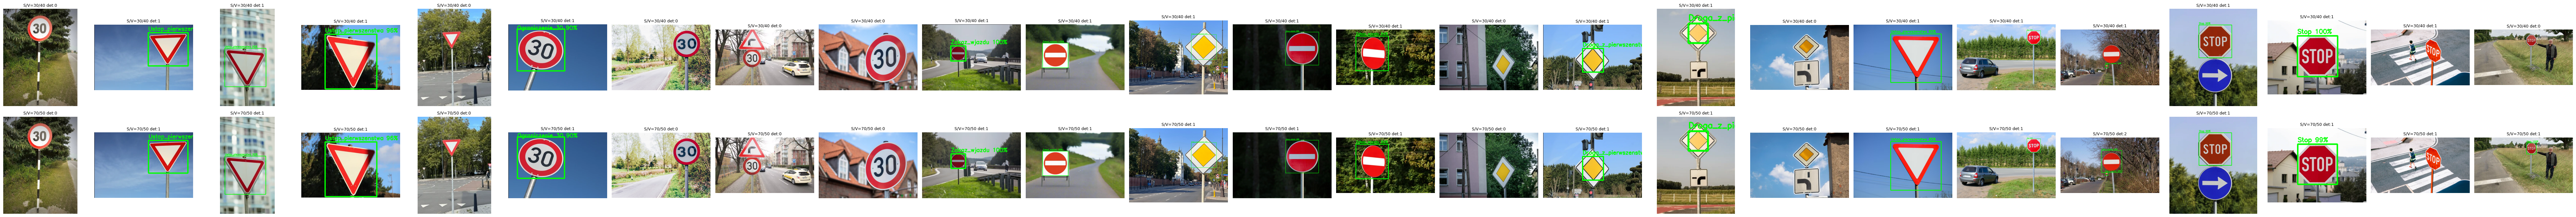

,prog pewnosci,detekcje (suma)
0,0.50,27
1,0.60,23
2,0.70,21
3,0.85,19
4,0.95,11


Zapisano CSV do ./wyniki_eksperymentow


In [3]:
# EKSPERYMENTY C i D: caly potok detekcji na zdjeciach drogowych
svm_model = joblib.load(MODEL_PATH)
test_imgs = [os.path.join(TEST_DIR, f) for f in sorted(os.listdir(TEST_DIR)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]


def run_detection(img, sv_min, prob_threshold):
    s_min, v_min = sv_min
    hsv = cv2.cvtColor(cv2.GaussianBlur(img, (5, 5), 0), cv2.COLOR_BGR2HSV)
    m1 = cv2.inRange(hsv, np.array([0, s_min, v_min], np.uint8), np.array([10, 255, 255], np.uint8))
    m2 = cv2.inRange(hsv, np.array([160, s_min, v_min], np.uint8), np.array([180, 255, 255], np.uint8))
    my = cv2.inRange(hsv, np.array([20, 100, 100], np.uint8), np.array([35, 255, 255], np.uint8))
    mask = m1 | m2 | my
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cand, acc = 0, []
    for cnt in contours:
        a = cv2.contourArea(cnt)
        if a < 600: continue
        x, y, w, h = cv2.boundingRect(cnt)
        if not (0.7 < w / float(h) < 1.3): continue
        ha = cv2.contourArea(cv2.convexHull(cnt))
        if ha == 0: continue
        sol = a / ha
        yel = cv2.countNonZero(my[y:y+h, x:x+w])
        red = cv2.countNonZero(cv2.bitwise_or(m1, m2)[y:y+h, x:x+w])
        if (yel > red and sol < 0.80) or (yel <= red and sol < 0.20): continue
        cand += 1
        mg = int(0.05 * w)
        x1, y1 = max(0, x - mg), max(0, y - mg)
        x2, y2 = min(img.shape[1], x + w + mg), min(img.shape[0], y + h + mg)
        roi = img[y1:y2, x1:x2]
        if roi.shape[0] <= 10 or roi.shape[1] <= 10: continue
        feat = hog_vector(roi).reshape(1, -1)
        pr = svm_model.predict_proba(feat)[0]
        if pr.max() >= prob_threshold:
            acc.append((svm_model.predict(feat)[0], pr.max(), (x1, y1, x2, y2)))
    return cand, acc


# EKSPERYMENT C: progi maski S/V
rowsC = []
for sv in [(20, 30), (30, 40), (50, 50), (70, 50), (90, 60)]:
    tc, ta = 0, 0
    for pth in test_imgs:
        im = cv2.imread(pth)
        if im is None: continue
        c, a = run_detection(im, sv, 0.85); tc += c; ta += len(a)
    rowsC.append({'S_min': sv[0], 'V_min': sv[1], 'kandydaci': tc, 'detekcje': ta, 'uwaga': 'trening' if sv == (30, 40) else ('detekcja-03' if sv == (70, 50) else '')})
dfC = pd.DataFrame(rowsC)
display(dfC)


def draw(img, acc):
    out = img.copy()
    for lab, pr, (x1, y1, x2, y2) in acc:
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(out, '%s %.0f%%' % (lab, pr * 100), (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)


n = len(test_imgs)
fig, ax = plt.subplots(2, n, figsize=(3.2 * n, 6.8)); ax = np.atleast_2d(ax)
if n == 1: ax = ax.reshape(2, 1)
for j, pth in enumerate(test_imgs):
    im = cv2.imread(pth)
    for r, sv in enumerate([(30, 40), (70, 50)]):
        _, a = run_detection(im, sv, 0.85)
        ax[r, j].imshow(draw(im, a)); ax[r, j].axis('off')
        ax[r, j].set_title('S/V=%d/%d det:%d' % (sv[0], sv[1], len(a)), fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, 'C_progi_SV.png'), bbox_inches='tight'); plt.show()

# EKSPERYMENT D: prog pewnosci
rowsD = []
for thr in [0.50, 0.60, 0.70, 0.85, 0.95]:
    t = 0
    for pth in test_imgs:
        im = cv2.imread(pth)
        if im is None: continue
        _, a = run_detection(im, (70, 50), thr); t += len(a)
    rowsD.append({'prog pewnosci': thr, 'detekcje (suma)': t})
dfD = pd.DataFrame(rowsD)
display(dfD)

# zapis tabel do CSV
for nm, df in [('A_kernel_C', dfA), ('B_hog', dfB), ('C_progi_SV', dfC), ('D_prog', dfD)]:
    df.to_csv(os.path.join(RESULTS_DIR, nm + '.csv'), index=False)
print('Zapisano CSV do', RESULTS_DIR)

In [4]:
# EKSPERYMENT E: ablacja - wyciecie ROI oraz filtr Gaussa (wymaga uruchomionej komorki 1)
def roi_variant(img, use_roi, use_blur):
    if not use_roi:
        return img
    src = cv2.GaussianBlur(img, (5, 5), 0) if use_blur else img
    hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV)
    lo1, hi1 = np.array([0, 30, 40], np.uint8), np.array([10, 255, 255], np.uint8)
    lo2, hi2 = np.array([160, 30, 40], np.uint8), np.array([180, 255, 255], np.uint8)
    loy, hiy = np.array([20, 100, 100], np.uint8), np.array([35, 255, 255], np.uint8)
    mask = cv2.inRange(hsv, lo1, hi1) | cv2.inRange(hsv, lo2, hi2) | cv2.inRange(hsv, loy, hiy)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return img
    bx, by, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    m = int(0.05 * bw)
    x1, y1 = max(0, bx - m), max(0, by - m)
    x2, y2 = min(img.shape[1], bx + bw + m), min(img.shape[0], by + bh + m)
    roi = img[y1:y2, x1:x2]
    return roi if roi.size else img


def feats_variant(use_roi, use_blur):
    cf = os.path.join(CACHE_DIR, 'feat_E_roi%d_blur%d.pkl' % (use_roi, use_blur))
    if os.path.exists(cf):
        d = joblib.load(cf); return d['X'], d['y']
    X, yy = [], []
    for cls in sorted(os.listdir(DATA_DIR)):
        cp = os.path.join(DATA_DIR, cls)
        if not os.path.isdir(cp):
            continue
        for fn in os.listdir(cp):
            img = cv2.imread(os.path.join(cp, fn))
            if img is None or img.size == 0:
                continue
            try:
                X.append(hog_vector(roi_variant(img, use_roi, use_blur))); yy.append(cls)
            except Exception:
                continue
    X, yy = np.array(X), np.array(yy)
    joblib.dump({'X': X, 'y': yy}, cf)
    return X, yy


variants = [('ROI + Gauss (projekt)', True, True), ('ROI bez Gaussa', True, False), ('bez ROI (cale zdjecie)', False, True)]
rowsE = []
for nazwa, ur, ub in variants:
    Xv, yv = feats_variant(ur, ub)
    Xtr, Xte, ytr, yte = train_test_split(Xv, yv, test_size=0.2, random_state=RANDOM_STATE)
    clf = SVC(kernel='linear', C=1.0); clf.fit(Xtr, ytr)
    rowsE.append({'wariant': nazwa, 'accuracy [%]': round(accuracy_score(yte, clf.predict(Xte)) * 100, 2)})
    del Xv, yv, Xtr, Xte; gc.collect()
dfE = pd.DataFrame(rowsE)
display(dfE)
dfE.to_csv(os.path.join(RESULTS_DIR, 'E_roi_gauss.csv'), index=False)
print('Zapisano E_roi_gauss.csv')

,wariant,accuracy [%]
0,ROI + Gauss (projekt),89.55
1,ROI bez Gaussa,89.73
2,bez ROI (cale zdjecie),99.88


Zapisano E_roi_gauss.csv
